In [18]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)
n_samples = 250

# Defining typical brands and models in the Egyptian market
brands_models = {
    'Hyundai': ['Elantra', 'Verna', 'Tucson'],
    'Kia': ['Cerato', 'Sportage', 'Picanto'],
    'Toyota': ['Corolla', 'Yaris'],
    'Fiat': ['Shahin', 'Tipo', 'Punto'],
    'Chevrolet': ['Optra', 'Aveo', 'Cruze']
}

data = []
for _ in range(n_samples):
    brand = np.random.choice(list(brands_models.keys()))
    model = np.random.choice(brands_models[brand])
    year = int(np.random.randint(1998, 2024))

    # Calculate Mileage (KM) based on car age
    age = 2026 - year
    km = int(age * np.random.randint(8000, 18000) + np.random.randint(0, 5000))
    if year > 2022:
        km = np.random.randint(5000, 25000)

    # Define baseline price according to brand and category
    base_price = 150000 if brand == 'Fiat' else 350000
    if model in ['Tucson', 'Sportage']: base_price = 900000
    if model == 'Shahin': base_price = 60000

    price = int(base_price * (1 + (year - 2000) * 0.05) * np.random.uniform(0.8, 1.2))
    price_str = f"{price:,} EGP"

    condition = "Nearly New" if km < 30000 else "Used"
    data.append([brand, model, year, km, price_str, condition])

# Create DataFrame
df = pd.DataFrame(data, columns=['Brand', 'Model', 'Year', 'KM', 'Price', 'Condition'])

# Injecting missing values and outliers for data cleaning practice
df.iloc[np.random.choice(n_samples, 15), 4] = np.nan  # Missing prices
df.iloc[np.random.choice(n_samples, 5), 3] = 950000   # Outlier KM

print(f"✅ Dataset generated successfully with {df.shape[0]} rows!")
display(df.head())

✅ Dataset generated successfully with 250 rows!


,Brand,Model,Year,KM,Price,Condition
0,Fiat,Shahin,2012,188446,"99,719 EGP",Used
1,Kia,Picanto,2020,78000,"728,312 EGP",Used
2,Toyota,Yaris,2018,72543,"753,429 EGP",Used
3,Kia,Cerato,1998,354925,"318,119 EGP",Used
4,Fiat,Shahin,2014,201074,"97,914 EGP",Used


In [19]:
# 1. Clean the 'Price' column by removing 'EGP' and commas
df['Price_Cleaned'] = df['Price'].str.replace(' EGP', '', regex=False)
df['Price_Cleaned'] = df['Price_Cleaned'].str.replace(',', '', regex=False)

# 2. Convert to numeric to handle NaN temporarily
df['Price_Cleaned'] = pd.to_numeric(df['Price_Cleaned'], errors='coerce')

# 3. Handle Missing Values using Groupby Imputation (Business Logic)
# Filling missing prices with the mean price of the specific Brand and Model
df['Price_Cleaned'] = df.groupby(['Brand', 'Model'])['Price_Cleaned'].transform(lambda x: x.fillna(x.mean()))

# Convert final cleaned price to integer
df['Price_Cleaned'] = df['Price_Cleaned'].astype(int)

print("✅ Step 2 Success: Data cleaning completed!")
print("Remaining missing values in Price_Cleaned:", df['Price_Cleaned'].isnull().sum())
display(df[['Brand', 'Model', 'Year', 'KM', 'Price', 'Price_Cleaned']].head())

✅ Step 2 Success: Data cleaning completed!
Remaining missing values in Price_Cleaned: 0


,Brand,Model,Year,KM,Price,Price_Cleaned
0,Fiat,Shahin,2012,188446,"99,719 EGP",99719
1,Kia,Picanto,2020,78000,"728,312 EGP",728312
2,Toyota,Yaris,2018,72543,"753,429 EGP",753429
3,Kia,Cerato,1998,354925,"318,119 EGP",318119
4,Fiat,Shahin,2014,201074,"97,914 EGP",97914


In [20]:
print("📊 --- Egyptian Used Car Market Insights --- 📊\n")

# 1. Market Share (Top Brands in our dataset)
print("🚗 1. Top Brands by Frequency:")
print(df['Brand'].value_counts())
print("-" * 50)

# 2. Average Price per Brand
print("\n💰 2. Average Price by Brand (Descending Order):")
brand_prices = df.groupby('Brand')['Price_Cleaned'].mean().sort_values(ascending=False).round(0)
for brand, price in brand_prices.items():
    print(f" - {brand}: {price:,.0f} EGP")
print("-" * 50)

# 3. Top 5 Most Used Models (Highest Average KM)
print("\n🛣️ 3. Top 5 Models by Average Mileage (KM):")
km_usage = df.groupby(['Brand', 'Model'])['KM'].mean().sort_values(ascending=False).head()
for (brand, model), km in km_usage.items():
    print(f" - {brand} {model}: {km:,.0f} KM")
print("-" * 50)

# 4. Average Price by Vehicle Condition
print("\n✨ 4. Average Price by Vehicle Condition:")
condition_prices = df.groupby('Condition')['Price_Cleaned'].mean().round(0)
for cond, price in condition_prices.items():
    print(f" - {cond}: {price:,.0f} EGP")

📊 --- Egyptian Used Car Market Insights --- 📊

🚗 1. Top Brands by Frequency:
Brand
Hyundai      57
Chevrolet    52
Toyota       50
Kia          46
Fiat         45
Name: count, dtype: int64
--------------------------------------------------

💰 2. Average Price by Brand (Descending Order):
 - Kia: 873,745 EGP
 - Hyundai: 779,140 EGP
 - Toyota: 528,944 EGP
 - Chevrolet: 528,148 EGP
 - Fiat: 161,014 EGP
--------------------------------------------------

🛣️ 3. Top 5 Models by Average Mileage (KM):
 - Chevrolet Cruze: 381,169 KM
 - Fiat Shahin: 263,373 KM
 - Kia Cerato: 240,345 KM
 - Hyundai Tucson: 234,461 KM
 - Chevrolet Optra: 234,076 KM
--------------------------------------------------

✨ 4. Average Price by Vehicle Condition:
 - Nearly New: 763,538 EGP
 - Used: 572,331 EGP


/tmp/ipykernel_5395/1023594906.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5395/1023594906.py:43: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5395/1023594906.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


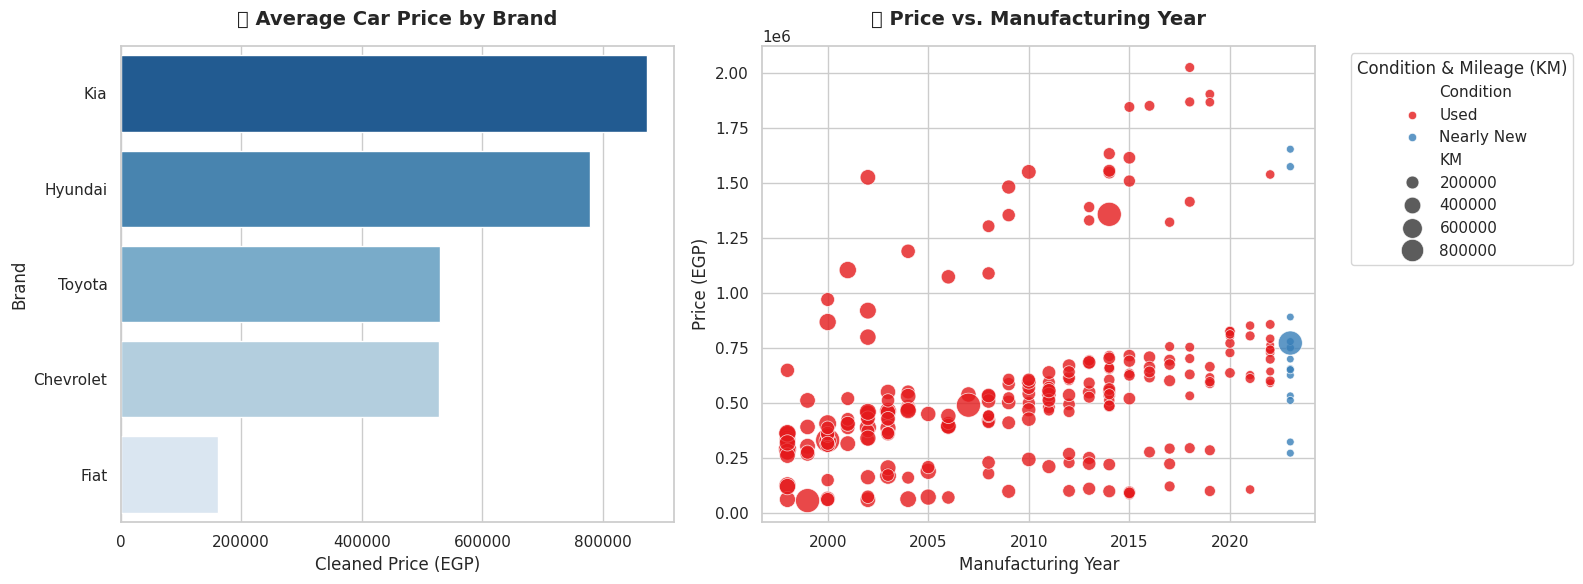

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style and background
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Car Price by Brand (Bar Plot)
brand_order = df.groupby('Brand')['Price_Cleaned'].mean().sort_values(ascending=False).index
sns.barplot(
    x='Price_Cleaned',
    y='Brand',
    data=df,
    ax=axes[0],
    order=brand_order,
    palette='Blues_r',
    errorbar=None
)
axes[0].set_title('💸 Average Car Price by Brand', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Cleaned Price (EGP)', fontsize=12)
axes[0].set_ylabel('Brand', fontsize=12)

# Plot 2: Price Trend over the Years vs Mileage (Scatter Plot)
sns.scatterplot(
    x='Year',
    y='Price_Cleaned',
    hue='Condition',
    size='KM',
    sizes=(30, 300),
    data=df,
    ax=axes[1],
    palette='Set1',
    alpha=0.8
)
axes[1].set_title('📈 Price vs. Manufacturing Year', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Manufacturing Year', fontsize=12)
axes[1].set_ylabel('Price (EGP)', fontsize=12)
axes[1].legend(title='Condition & Mileage (KM)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent clipping of labels
plt.tight_layout()
plt.show()